In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import roc_auc_score

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [32]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [33]:
def get_concepts(label):
    c = torch.zeros(6)

    if label in [0, 2, 3, 4, 6]:
        c[0] = 1
    if label == 1:
        c[1] = 1
    if label in [5, 7, 9]:
        c[2] = 1
    if label in [0, 2, 3, 4, 6]:
        c[3] = 1
    if label == 5:
        c[4] = 1
    if label == 8:
        c[5] = 1

    return c

In [34]:
class ConceptDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        c = get_concepts(y)
        return x, y, c
    
train_data = ConceptDataset(train_dataset)
test_data = ConceptDataset(test_dataset)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Backbone CNN
class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Linear(64 * 7 * 7, 128)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


# 1: Baseline Classifier: x → y
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CNNBackbone()
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        h = self.backbone(x)
        return self.classifier(h)


# 2: Concept Predictor: x → c
class ConceptModel(nn.Module):
    def __init__(self, num_concepts=6):
        super().__init__()
        self.backbone = CNNBackbone()
        self.head = nn.Linear(128, num_concepts)

    def forward(self, x):
        h = self.backbone(x)
        return torch.sigmoid(self.head(h))  # multi-label output


# 3: Concept Bottleneck Model: x → c → y
class CBM(nn.Module):
    def __init__(self, concept_model, num_concepts=6):
        super().__init__()
        self.concept_model = concept_model
        self.classifier = nn.Linear(num_concepts, 10)

    def forward(self, x):
        # freeze concept model during forward
        with torch.no_grad():
            c = self.concept_model(x)

        return self.classifier(c)


# 4: Hybrid CBM: y = f(c) + s(x)
class HybridCBM(nn.Module):
    def __init__(self, num_concepts=6, dropout_p=0.5):
        super().__init__()

        self.backbone = CNNBackbone()

        # concept pathway
        self.concept_head = nn.Linear(128, num_concepts)
        self.label_from_concepts = nn.Linear(num_concepts, 10)

        # side channel
        self.side_head = nn.Linear(128, 10)
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        h = self.backbone(x)

        # concept path
        c = torch.sigmoid(self.concept_head(h))
        y_c = self.label_from_concepts(c)

        # side channel path
        y_s = self.side_head(self.dropout(h))

        # combine logits
        y = y_c + y_s

        return y, c

In [36]:
def evaluate_full(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)

            output = model(x)

            # handle hybrid
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

            probs = torch.softmax(logits, dim=1)

            # accuracy
            preds = probs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            # store for AUROC
            all_probs.append(probs.cpu())
            all_labels.append(y.cpu())

    acc = correct / total

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # AUROC (multiclass)
    auroc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

    return acc, auroc

Baseline Classifier
- Training
- Accuracy
- AUROC

In [37]:
def train_baseline(model, loader, epochs=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch}: {total_loss:.3f}")

baseline = BaselineModel()
train_baseline(baseline, train_loader)

Epoch 0: 401.296
Epoch 1: 263.910
Epoch 2: 226.928
Epoch 3: 205.015
Epoch 4: 184.752


In [38]:
acc, auroc = evaluate_full(baseline, test_loader)
print("Baseline Accuracy:", acc)
print("Baseline AUROC:", auroc)


Baseline Accuracy: 0.9049
Baseline AUROC: 0.993756961111111


Concept Predictor: 
- Training
- F1 Score
- Macro-average

In [39]:
def train_concept(model, loader, epochs=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCELoss()

    for epoch in range(epochs):
        total_loss = 0

        for x, _, c in loader:
            x, c = x.to(device), c.to(device)

            optimizer.zero_grad()
            preds = model(x)
            loss = loss_fn(preds, c)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch}: {total_loss:.3f}")

concept_model = ConceptModel()
train_concept(concept_model, train_loader)

Epoch 0: 41.129
Epoch 1: 16.224
Epoch 2: 11.725
Epoch 3: 8.850
Epoch 4: 7.044


In [40]:
from sklearn.metrics import f1_score

def evaluate_concepts(model, loader, threshold=0.5):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, _, c in loader:
            x = x.to(device)
            c = c.to(device)

            preds = model(x)

            # convert probabilities → binary (0/1)
            preds = (preds > threshold).float()

            all_preds.append(preds.cpu())
            all_targets.append(c.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    num_concepts = all_preds.shape[1]

    f1_per_concept = []

    for i in range(num_concepts):
        f1 = f1_score(all_targets[:, i], all_preds[:, i])
        f1_per_concept.append(f1)

    macro_f1 = sum(f1_per_concept) / num_concepts

    return f1_per_concept, macro_f1

In [41]:
f1_per_concept, macro_f1 = evaluate_concepts(concept_model, test_loader)

for i, f1 in enumerate(f1_per_concept):
    print(f"Concept {i} F1: {f1:.4f}")

print("Macro F1:", macro_f1)

Concept 0 F1: 0.9950
Concept 1 F1: 0.9880
Concept 2 F1: 0.9988
Concept 3 F1: 0.9951
Concept 4 F1: 0.9782
Concept 5 F1: 0.9829
Macro F1: 0.9896706542966598


Concept Bottleneck Model: 
- Training
- Accuracy
- AUROC
- Concept prediction metrics

In [42]:
cbm = CBM(concept_model).to(device)

optimizer = optim.Adam(cbm.classifier.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(5):
    total_loss = 0

    for x, y, _ in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = cbm(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: {total_loss:.3f}")


Epoch 0: 1599.308
Epoch 1: 1138.215
Epoch 2: 1005.709
Epoch 3: 955.157
Epoch 4: 930.951


In [43]:
acc, auroc = evaluate_full(cbm, test_loader)
print("CBM Acc:", acc)
print("CBM AUROC:", auroc)

CBM Acc: 0.493
CBM AUROC: 0.8850875111111112


In [44]:
f1_per_concept, macro_f1 = evaluate_concepts(cbm.concept_model, test_loader)

print("CBM Concept F1 per concept:", f1_per_concept)
print("CBM Macro F1:", macro_f1)

CBM Concept F1 per concept: [0.9950039968025579, 0.987987987987988, 0.998834304746045, 0.9951044060345688, 0.9781615033011681, 0.9829317269076305]
CBM Macro F1: 0.9896706542966598


Hybrid CBM with side channel:
- Test accuracy
- AUROC
- Plot
- Concept Prediction Quality

In [45]:
dropouts = [0.0, 0.3, 0.5, 0.7]

results = []

for p in dropouts:
    model = HybridCBM(dropout_p=p).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(3):
        for x, y, c in train_loader:
            x, y, c = x.to(device), y.to(device), c.to(device)

            optimizer.zero_grad()
            y_pred, c_pred = model(x)

            loss = nn.CrossEntropyLoss()(y_pred, y) + nn.BCELoss()(c_pred, c)
            loss.backward()
            optimizer.step()


    acc, auroc = evaluate_full(model, test_loader)
    results.append((p, acc, auroc))


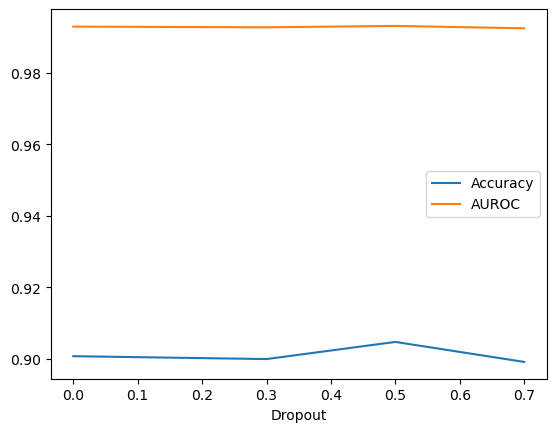

In [46]:
ps = [r[0] for r in results]
accs = [r[1] for r in results]
aurocs = [r[2] for r in results]

plt.plot(ps, accs, label="Accuracy")
plt.plot(ps, aurocs, label="AUROC")
plt.xlabel("Dropout")
plt.legend()
plt.show()

In [47]:
from sklearn.metrics import f1_score

def evaluate_concepts_hybrid(model, loader, threshold=0.5):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, _, c in loader:
            x = x.to(device)
            c = c.to(device)

            _, preds = model(x)  # 🔥 get concept predictions

            preds = (preds > threshold).float()

            all_preds.append(preds.cpu())
            all_targets.append(c.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    num_concepts = all_preds.shape[1]

    f1_per_concept = []
    for i in range(num_concepts):
        f1 = f1_score(all_targets[:, i], all_preds[:, i], zero_division=0)
        f1_per_concept.append(f1)

    macro_f1 = sum(f1_per_concept) / num_concepts

    return f1_per_concept, macro_f1

In [48]:
f1_per_concept_h, macro_f1_h = evaluate_concepts_hybrid(model, test_loader)

print("Hybrid Concept F1 per concept:", f1_per_concept_h)
print("Hybrid Macro F1:", macro_f1_h)

Hybrid Concept F1 per concept: [0.9933167082294264, 0.9838872104733132, 0.9990006662225184, 0.9931172069825437, 0.9761784085149519, 0.9803921568627451]
Hybrid Macro F1: 0.9876487262142497


Intervention Procedure

In [49]:
def predict_from_concepts(model, c):
    """
    Takes concept vector and returns logits using ONLY concept pathway
    """

    if hasattr(model, "label_from_concepts"):  
        # Hybrid
        return model.label_from_concepts(c)
    else:
        # CBM
        return model.classifier(c)

In [50]:
def intervention_experiment(model, loader, num_concepts=6):
    model.eval()

    prob_changes = torch.zeros(num_concepts)
    flip_rates = torch.zeros(num_concepts)
    counts = 0

    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(device)

            output = model(x)

            # handle outputs
            if isinstance(output, tuple):
                logits, c = output
            else:
                # CBM case → need concepts manually
                c = model.concept_model(x)
                logits = model.classifier(c)

            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            for i in range(num_concepts):

                # clone concepts
                c_flipped = c.clone()

                # flip ONE concept
                c_flipped[:, i] = 1 - c_flipped[:, i]

                # recompute logits using concepts ONLY
                new_logits = predict_from_concepts(model, c_flipped)

                new_probs = torch.softmax(new_logits, dim=1)
                new_preds = new_probs.argmax(dim=1)

                # measure probability change
                prob_change = (new_probs - probs).abs().mean()

                # measure label flip
                flip = (new_preds != preds).float().mean()

                prob_changes[i] += prob_change.item()
                flip_rates[i] += flip.item()

            counts += 1

    prob_changes /= counts
    flip_rates /= counts

    return prob_changes, flip_rates

In [51]:
prob_changes, flip_rates = intervention_experiment(model, test_loader)

for i in range(len(prob_changes)):
    print(f"Concept {i}:")
    print("  Avg prob change:", prob_changes[i].item())
    print("  Flip rate:", flip_rates[i].item())

Concept 0:
  Avg prob change: 0.16154472529888153
  Flip rate: 0.7177547812461853
Concept 1:
  Avg prob change: 0.15828156471252441
  Flip rate: 0.6190286874771118
Concept 2:
  Avg prob change: 0.161463662981987
  Flip rate: 0.8165804147720337
Concept 3:
  Avg prob change: 0.1630028486251831
  Flip rate: 0.818670392036438
Concept 4:
  Avg prob change: 0.16119445860385895
  Flip rate: 0.8151870965957642
Concept 5:
  Avg prob change: 0.16184952855110168
  Flip rate: 0.9024681448936462


In [52]:
importance = prob_changes.numpy()
ranking = importance.argsort()[::-1]

print("Concept importance ranking:")
for i in ranking:
    print(f"Concept {i}: {importance[i]:.4f}")

Concept importance ranking:
Concept 3: 0.1630
Concept 5: 0.1618
Concept 0: 0.1615
Concept 2: 0.1615
Concept 4: 0.1612
Concept 1: 0.1583
